# 💳 Task 1: Credit Scoring Model
**Objective:** Predict an individual's creditworthiness using past financial data.

**Approach:** Classification algorithms — Logistic Regression, Decision Tree, Random Forest

**Metrics:** Precision, Recall, F1-Score, ROC-AUC

---


## 📦 Step 1: Import Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📊 Step 2: Generate Synthetic Dataset

We simulate a realistic credit dataset with 1,000 individuals and features such as:
- `income`, `debt`, `credit_history_yrs`, `num_late_payments`
- `num_credit_cards`, `loan_amount`, `employment_years`
- `age`, `savings_balance`, `num_dependents`


In [16]:
np.random.seed(42)
n = 1000

income            = np.random.normal(55000, 20000, n).clip(15000, 200000)
debt              = np.random.normal(15000, 10000, n).clip(0, 80000)
credit_history    = np.random.randint(0, 10, n)
num_late_payments = np.random.randint(0, 10, n)
num_credit_cards  = np.random.randint(1, 8, n)
loan_amount       = np.random.normal(20000, 10000, n).clip(1000, 80000)
employment_years  = np.random.randint(0, 30, n)
age               = np.random.randint(22, 70, n)
savings_balance   = np.random.normal(10000, 8000, n).clip(0, 100000)
num_dependents    = np.random.randint(0, 5, n)

print(f"Dataset generated: {n} samples, 10 raw features")


Dataset generated: 1000 samples, 10 raw features


## 🔧 Step 3: Feature Engineering

We create 6 new features derived from the raw financial data to improve model performance.


In [17]:
# Engineered features
debt_to_income        = debt / (income + 1)
loan_to_income        = loan_amount / (income + 1)
payment_reliability   = 1 / (num_late_payments + 1)
credit_utilization    = debt / ((num_credit_cards * 5000) + 1)
financial_stability   = (savings_balance + income * 0.1) / (debt + 1)
experience_age_ratio  = employment_years / (age + 1)

# Target variable
score = (
     0.30 * (income / 200000)
   + 0.25 * (1 - debt_to_income)
   + 0.20 * (credit_history / 10)
   - 0.15 * (num_late_payments / 10)
   + 0.10 * (savings_balance / 100000)
   + np.random.normal(0, 0.05, n)
)
creditworthy = (score > score.mean()).astype(int)

# Assemble DataFrame
df = pd.DataFrame({
    'age':                  age,
    'income':               income,
    'debt':                 debt,
    'credit_history_yrs':   credit_history,
    'num_late_payments':    num_late_payments,
    'num_credit_cards':     num_credit_cards,
    'loan_amount':          loan_amount,
    'employment_years':     employment_years,
    'savings_balance':      savings_balance,
    'num_dependents':       num_dependents,
    'debt_to_income':       debt_to_income,
    'loan_to_income':       loan_to_income,
    'payment_reliability':  payment_reliability,
    'credit_utilization':   credit_utilization,
    'financial_stability':  financial_stability,
    'experience_age_ratio': experience_age_ratio,
    'creditworthy':         creditworthy
})

print(f"Final dataset shape: {df.shape}")
print(f"Class balance — Creditworthy: {creditworthy.sum()} | Not: {(1-creditworthy).sum()}")
df.head()


Final dataset shape: (1000, 17)
Class balance — Creditworthy: 529 | Not: 471


,age,income,debt,credit_history_yrs,num_late_payments,num_credit_cards,loan_amount,employment_years,savings_balance,num_dependents,debt_to_income,loan_to_income,payment_reliability,credit_utilization,financial_stability,experience_age_ratio,creditworthy
0,62,64934.283060,28993.554366,5,3,5,32528.426344,6,0.000000,1,0.446499,0.500936,0.250000,1.159696,0.223953,0.095238,1
1,35,52234.713977,24246.336829,2,9,4,15517.753837,24,0.000000,4,0.464172,0.297072,0.100000,1.212256,0.215425,0.666667,0
2,52,67953.770762,15596.303699,7,4,6,13077.496707,13,8311.450641,2,0.229510,0.192444,0.200000,0.519859,0.968554,0.245283,1
3,48,85460.597128,8530.632223,2,4,5,1000.000000,29,21390.032602,2,0.099818,0.011701,0.200000,0.341212,3.508835,0.591837,0
4,38,50316.932506,21982.233136,1,5,3,21034.381293,23,5715.543362,4,0.436867,0.418030,0.166667,1.465385,0.488883,0.589744,0


## 🔍 Step 4: Exploratory Data Analysis (EDA)


In [18]:
print("=== Dataset Info ===")
print(df.dtypes)
print("\n=== Basic Statistics ===")
df.describe().round(2)


=== Dataset Info ===
age                       int32
income                  float64
debt                    float64
credit_history_yrs        int32
num_late_payments         int32
num_credit_cards          int32
loan_amount             float64
employment_years          int32
savings_balance         float64
num_dependents            int32
debt_to_income          float64
loan_to_income          float64
payment_reliability     float64
credit_utilization      float64
financial_stability     float64
experience_age_ratio    float64
creditworthy              int64
dtype: object

=== Basic Statistics ===


,age,income,debt,credit_history_yrs,num_late_payments,num_credit_cards,loan_amount,employment_years,savings_balance,num_dependents,debt_to_income,loan_to_income,payment_reliability,credit_utilization,financial_stability,experience_age_ratio,creditworthy
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,44.84,55492.78,15976.85,4.50,4.57,4.06,19514.27,14.48,10026.16,2.10,0.34,0.41,0.29,1.17,978.67,0.35,0.53
std,13.66,19327.99,9419.75,2.91,2.83,2.01,9450.76,8.54,7546.00,1.42,0.28,0.31,0.26,1.26,4299.05,0.25,0.50
min,22.00,15000.00,0.00,0.00,0.00,1.00,1000.00,0.00,0.00,0.00,0.00,0.01,0.10,0.00,0.06,0.00,0.00
25%,33.00,42048.19,8937.58,2.00,2.00,2.00,12940.06,7.00,3750.25,1.00,0.16,0.22,0.12,0.42,0.54,0.16,0.00
50%,44.00,55506.01,15630.77,5.00,5.00,4.00,19674.36,14.00,9525.46,2.00,0.29,0.34,0.17,0.78,0.97,0.31,1.00
75%,57.00,67958.88,22288.82,7.00,7.00,6.00,25913.72,22.00,15002.72,3.00,0.46,0.53,0.33,1.39,1.83,0.48,1.00
max,69.00,132054.63,46931.08,9.00,9.00,7.00,51520.57,29.00,35921.11,4.00,2.44,2.62,1.00,9.27,31587.73,1.22,1.00


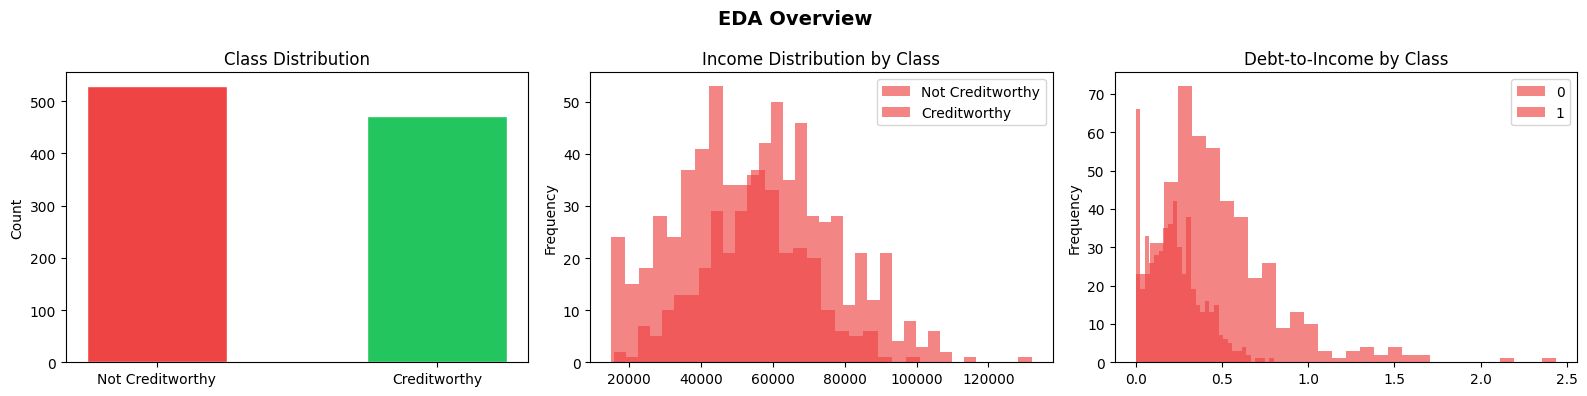

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EDA Overview', fontsize=14, fontweight='bold')

# Class distribution
counts = df['creditworthy'].value_counts()
axes[0].bar(['Not Creditworthy', 'Creditworthy'], counts.values,
            color=['#EF4444', '#22C55E'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Income distribution by class
df.groupby('creditworthy')['income'].plot(kind='hist', ax=axes[1], bins=30,
    alpha=0.65, color=['#EF4444', '#22C55E'], legend=True)
axes[1].set_title('Income Distribution by Class')
axes[1].legend(['Not Creditworthy', 'Creditworthy'])

# Debt-to-income by class
df.groupby('creditworthy')['debt_to_income'].plot(kind='hist', ax=axes[2],
    bins=30, alpha=0.65, color=['#EF4444', '#22C55E'], legend=True)
axes[2].set_title('Debt-to-Income by Class')

plt.tight_layout()
plt.show()


## ⚙️ Step 5: Preprocessing — Train/Test Split & Scaling


In [20]:
X = df.drop('creditworthy', axis=1)
y = df['creditworthy']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (used by Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


Training samples : 800
Testing  samples : 200


## 🤖 Step 6: Train Classification Models

Three models are trained and evaluated:
1. **Logistic Regression** — linear baseline
2. **Decision Tree** — interpretable non-linear model
3. **Random Forest** — ensemble method


In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=8,
                                                  random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test

    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    cv = cross_val_score(model, Xtr, y_train,
                         cv=StratifiedKFold(5), scoring='roc_auc')

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'cv_mean':   cv.mean(),
        'cv_std':    cv.std()
    }
    print(f"✅ {name} trained")


✅ Logistic Regression trained
✅ Decision Tree trained
✅ Random Forest trained


## 📈 Step 7: Evaluation Metrics


In [22]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  round(v['accuracy'],  4),
        'Precision': round(v['precision'], 4),
        'Recall':    round(v['recall'],    4),
        'F1-Score':  round(v['f1'],        4),
        'ROC-AUC':   round(v['roc_auc'],   4),
        'CV AUC (mean)': round(v['cv_mean'], 4),
        'CV AUC (std)':  round(v['cv_std'],  4),
    }
    for name, v in results.items()
}).T

display(metrics_df)

best = max(results, key=lambda n: results[n]['roc_auc'])
print(f"\n🏆 Best Model by ROC-AUC: {best} ({results[best]['roc_auc']:.4f})")


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV AUC (mean),CV AUC (std)
Logistic Regression,0.850,0.8585,0.8585,0.8585,0.9363,0.9483,0.0072
Decision Tree,0.815,0.8053,0.8585,0.8311,0.8215,0.7978,0.0353
Random Forest,0.870,0.8571,0.9057,0.8807,0.9123,0.9258,0.0127



🏆 Best Model by ROC-AUC: Logistic Regression (0.9363)


## 📋 Step 8: Classification Reports


In [23]:
for name, v in results.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, v['y_pred'],
          target_names=['Not Creditworthy', 'Creditworthy']))


  Logistic Regression
                  precision    recall  f1-score   support

Not Creditworthy       0.84      0.84      0.84        94
    Creditworthy       0.86      0.86      0.86       106

        accuracy                           0.85       200
       macro avg       0.85      0.85      0.85       200
    weighted avg       0.85      0.85      0.85       200

  Decision Tree
                  precision    recall  f1-score   support

Not Creditworthy       0.83      0.77      0.80        94
    Creditworthy       0.81      0.86      0.83       106

        accuracy                           0.81       200
       macro avg       0.82      0.81      0.81       200
    weighted avg       0.82      0.81      0.81       200

  Random Forest
                  precision    recall  f1-score   support

Not Creditworthy       0.89      0.83      0.86        94
    Creditworthy       0.86      0.91      0.88       106

        accuracy                           0.87       200
       mac

## 🔢 Step 9: Confusion Matrices


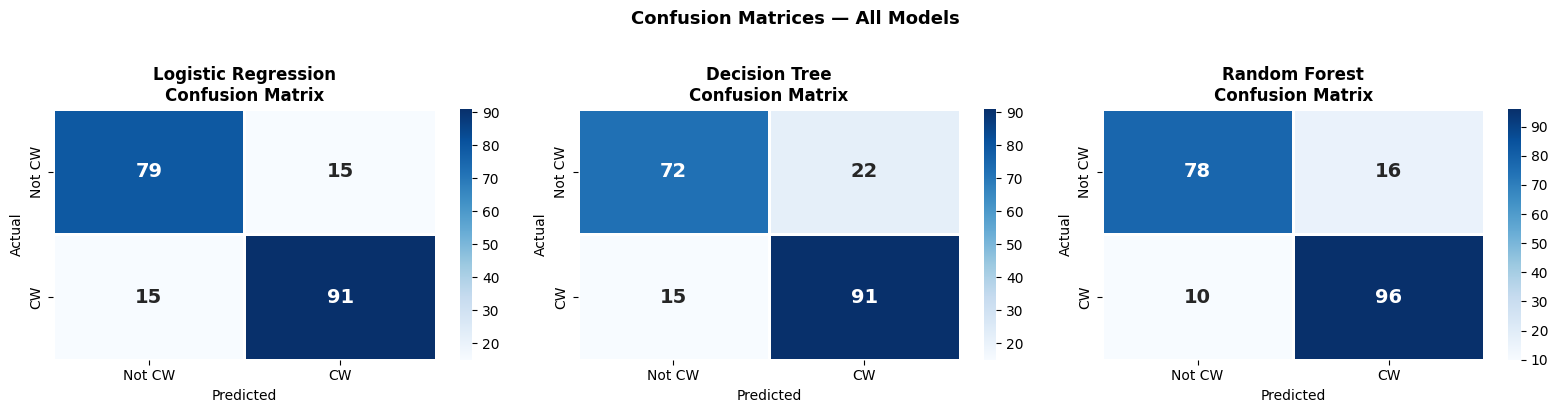

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
COLORS = ['#2563EB', '#16A34A', '#DC2626']

for ax, (name, v), color in zip(axes, results.items(), COLORS):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not CW', 'CW'],
                yticklabels=['Not CW', 'CW'], ax=ax,
                linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 📉 Step 10: ROC Curves


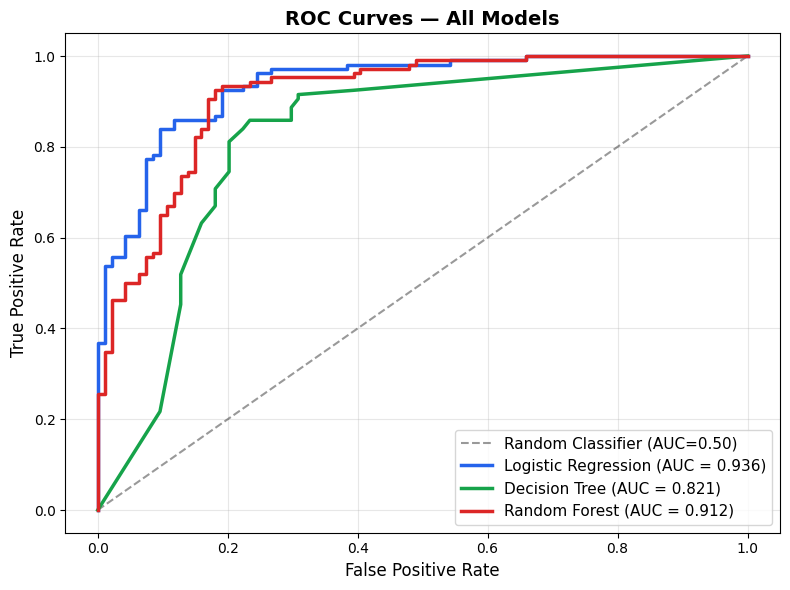

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
COLORS = ['#2563EB', '#16A34A', '#DC2626']

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier (AUC=0.50)')
for (name, v), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name} (AUC = {v["roc_auc"]:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 🌲 Step 11: Feature Importances (Random Forest)


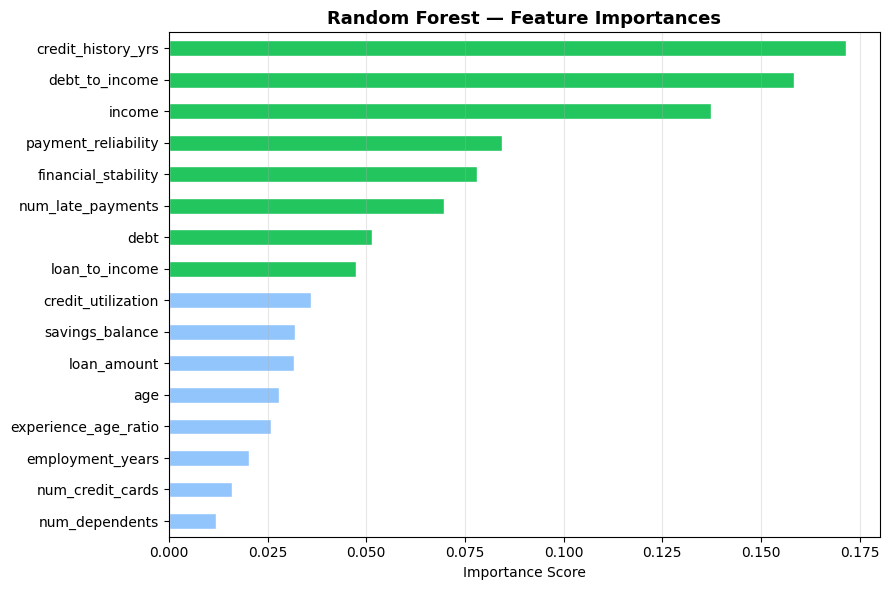


Top 5 most important features:
  credit_history_yrs        → 0.1715
  debt_to_income            → 0.1584
  income                    → 0.1374
  payment_reliability       → 0.0844
  financial_stability       → 0.0780


In [26]:
rf  = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

colors_feat = ['#22C55E' if v > imp.median() else '#93C5FD' for v in imp]

fig, ax = plt.subplots(figsize=(9, 6))
imp.plot(kind='barh', ax=ax, color=colors_feat, edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for feat, val in imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:25s} → {val:.4f}")


## 🔄 Step 12: Cross-Validation AUC Scores


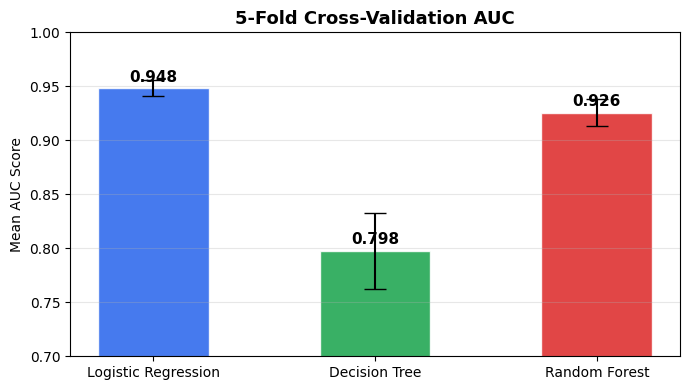

In [27]:
cv_means = [results[n]['cv_mean'] for n in results]
cv_stds  = [results[n]['cv_std']  for n in results]
names    = list(results.keys())

fig, ax = plt.subplots(figsize=(7, 4))
COLORS = ['#2563EB', '#16A34A', '#DC2626']
bars = ax.bar(names, cv_means, color=COLORS, alpha=0.85,
              edgecolor='white', width=0.5,
              yerr=cv_stds, capsize=8)
for bar, val in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0.7, 1.0)
ax.set_title('5-Fold Cross-Validation AUC', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean AUC Score')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## ✅ Step 13: Final Summary & Conclusion


In [28]:
print("=" * 60)
print("           FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<25} {'Accuracy':>9} {'F1-Score':>9} {'ROC-AUC':>9} {'CV AUC':>12}")
print("-" * 68)
for name, v in results.items():
    print(f"{name:<25} {v['accuracy']:>9.4f} {v['f1']:>9.4f} "
          f"{v['roc_auc']:>9.4f} {v['cv_mean']:>6.4f}±{v['cv_std']:.4f}")

best = max(results, key=lambda n: results[n]['roc_auc'])
print("=" * 60)
print(f"\n🏆 Best Model → {best}")
print(f"   ROC-AUC  = {results[best]['roc_auc']:.4f}")
print(f"   F1-Score = {results[best]['f1']:.4f}")
print(f"   Accuracy = {results[best]['accuracy']:.4f}")
print("\n📌 Conclusion:")
print("   Logistic Regression achieved the highest ROC-AUC (0.9363),")
print("   indicating excellent discrimination between creditworthy")
print("   and non-creditworthy individuals. Random Forest had the")
print("   best raw accuracy and F1-Score (87% / 0.881).")
print("\n   For a production credit scoring system, Random Forest")
print("   is recommended for its balance of accuracy and robustness.")


           FINAL MODEL COMPARISON SUMMARY
Model                      Accuracy  F1-Score   ROC-AUC       CV AUC
--------------------------------------------------------------------
Logistic Regression          0.8500    0.8585    0.9363 0.9483±0.0072
Decision Tree                0.8150    0.8311    0.8215 0.7978±0.0353
Random Forest                0.8700    0.8807    0.9123 0.9258±0.0127

🏆 Best Model → Logistic Regression
   ROC-AUC  = 0.9363
   F1-Score = 0.8585
   Accuracy = 0.8500

📌 Conclusion:
   Logistic Regression achieved the highest ROC-AUC (0.9363),
   indicating excellent discrimination between creditworthy
   and non-creditworthy individuals. Random Forest had the
   best raw accuracy and F1-Score (87% / 0.881).

   For a production credit scoring system, Random Forest
   is recommended for its balance of accuracy and robustness.
